In [2]:
import scanpy as sc 
import pandas as pd
import numpy as np
print("Environment ready")

Environment ready


In [3]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [4]:
# look at the cell info
adata.obs.head()

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [5]:
# look at the gene info 
adata.var.head()

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


In [6]:
adata



AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [7]:
type(adata)

anndata.AnnData

In [8]:
adata.X[:5,:5].toarray()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)

In [9]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [10]:
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
index,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390


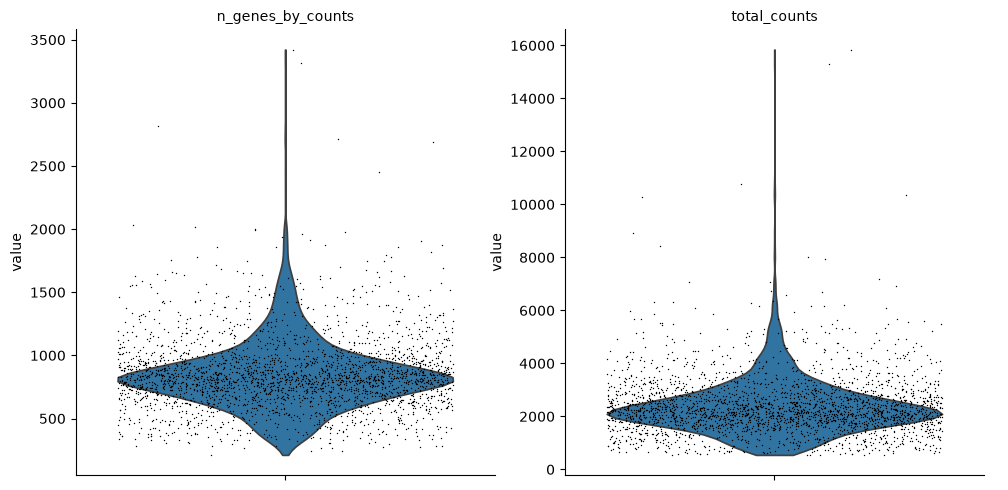

In [11]:
# plotting the number of genes detected in each cell shows us that most cells express about 900 genes and few express a lot more 
# it also shows us that most cells have about 2000 transcripts and few have more than that
# this plots the data from 2 cols in adata.obs
sc.pl.violin(
    adata, 
    ["n_genes_by_counts", "total_counts"], 
    jitter=0.4, 
    multi_panel=True
)

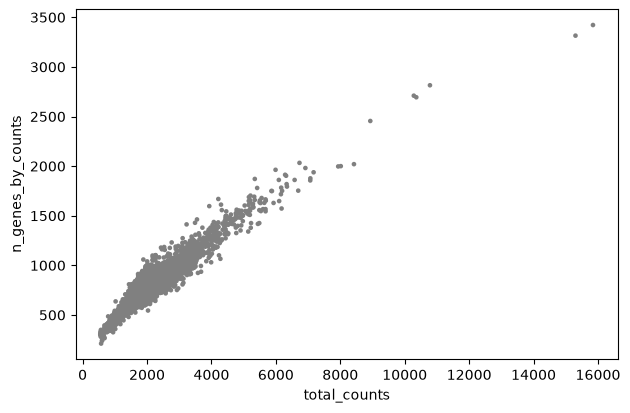

In [12]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts"
)
# the more rna molecules there are the more genes they express, but they're clustered in a certain range

In [13]:
# since obs is a pd df, you use 2 brackets to select 2 cols 
# describe takes those 2 cols and tells you metrics for all cells
# count tells you the number of cells, mean tells how many genes on average each cell expresses, and how many rnas seen in each cell on average 

adata.obs[["n_genes_by_counts", "total_counts"]].describe()


,n_genes_by_counts,total_counts
count,2700.000000,2700.000000
mean,846.994074,2366.900391
std,282.104964,1094.262085
min,212.000000,548.000000
25%,690.000000,1757.750000
50%,817.000000,2197.000000
75%,953.250000,2763.000000
max,3422.000000,15844.000000


In [ ]:
# creates a new col in var called mt that takes all the mt genes and their data
adata.var["mt"] = adata.var_names.str.startswith("MT")

# calculates qc metrics on the mt genes 
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],  
    inplace=True
)

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,75.0,4.330733,3.097893
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,190.0,5.252274,3.875179
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,34.0,3.555348,1.079708
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,52.0,3.970292,1.970443
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,14.0,2.708050,1.427115


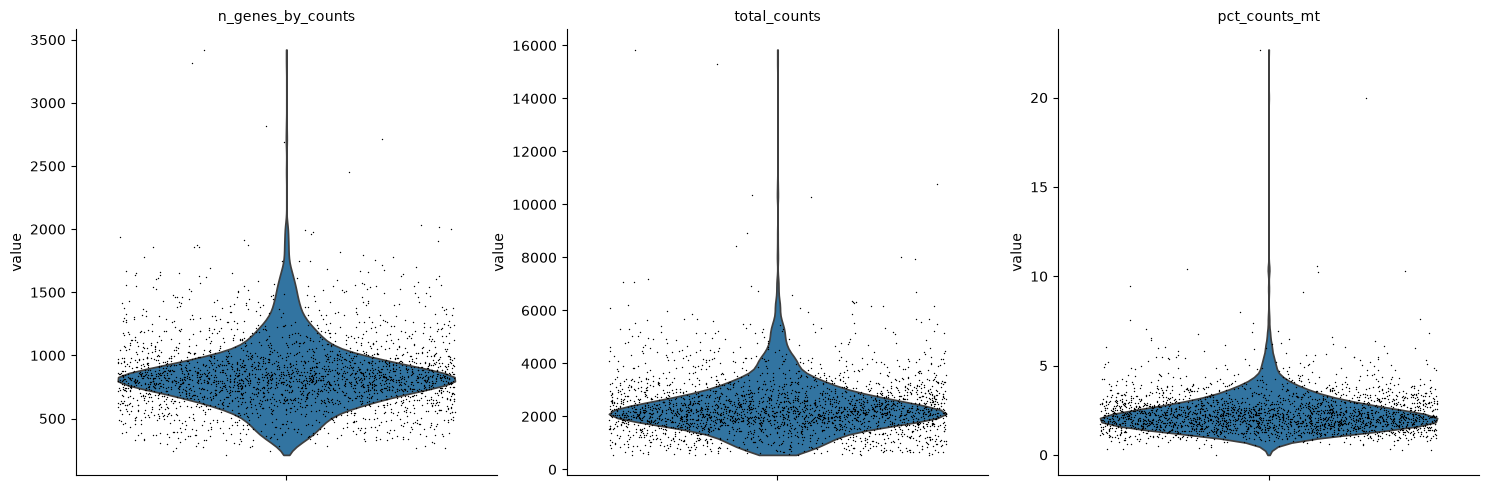

In [ ]:
sc.pl.violin(
    adata, 
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"], 
    jitter=0.4, 
    multi_panel=True
)
# i notice that most cells have 900 genes in them
# most cells have 2000 rna molecules in them 
# most cells have 3% mt genes making up all genes 